analysis R. static overview. each pair of regions, each category of clause.

For two regions, r1 and r2, compare the clauses one by one; a regulation difference is counted whenever one is 1 and the other is 0.

In [2]:
import pandas as pd
import numpy as np
from itertools import combinations
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.utils import get_column_letter

In [12]:
# =========================
# 1. File paths
# =========================

input_path = "dataset\\regions_regulation.xlsx"
output_path = "dataset\\out_R" #\\region_pair_difference_analysis.xlsx

# =========================
# 2. Read regulation matrix
# =========================

df = pd.read_excel(input_path)
# df.head(), df.shape

In [13]:
# 清理列名
df.columns = [str(c).strip() for c in df.columns]

# 方法 1：直接删除并重新赋值（推荐，更符合 Pandas 最佳实践）
df = df.drop(columns=['Bangladesh', 'Pakistan'])

# 方法 2：原址修改（inplace）
# df.drop(columns=['Bangladesh', 'Pakistan'], inplace=True)

print("Columns:")
print(df.columns.tolist())
print("\nShape:", df.shape)

Columns:
['Clause', 'California', 'Texas', 'Germany', 'Turkey', 'Egypt', 'Vietnam', 'Nigeria', 'India', 'Saudi']

Shape: (46, 10)


In [14]:
# =========================
# 3. Identify clause/category/region columns
# =========================
# 这里做得比较鲁棒：
# - clause column: 优先找包含 clause 的列
# - category column: 优先找 category/group/type
# - region columns: 除了 clause/category/description 之外的列

lower_cols = {c.lower(): c for c in df.columns}

clause_col = None
# for key in ["clause", "clause id", "clause_id", "id"]:
#     if key in lower_cols:
#         clause_col = lower_cols[key]
#         break

if clause_col is None:
    # 如果没有明确 clause 列，就默认第一列是 clause
    clause_col = df.columns[0]

category_col = None
# for c in df.columns:
#     lc = c.lower()
#     if "category" in lc or "group" in lc or "type" in lc:
#         category_col = c
#         break

# 如果你的表里有 description / text / definition / clause 这类列，不要当成地区
non_region_cols = {clause_col}
# if category_col is not None:
#     non_region_cols.add(category_col)

for c in df.columns:
    lc = c.lower()
    if any(x in lc for x in ["description", "definition", "text", "explanation", "note"]):
        non_region_cols.add(c)

region_cols = [c for c in df.columns if c not in non_region_cols]

print("\nClause column:", clause_col)
print("Category column:", category_col)
print("Region columns:", region_cols)


Clause column: Clause
Category column: None
Region columns: ['California', 'Texas', 'Germany', 'Turkey', 'Egypt', 'Vietnam', 'Nigeria', 'India', 'Saudi']


In [15]:
# =========================
# 4. Infer category if needed
# =========================

def infer_category_from_clause(x):
    """
    根据 clause id 推断 5 类:
    P, CR, C, R, O
    """
    if pd.isna(x):
        return "O"

    s = str(x).strip().upper()

    if s.startswith("CR"):
        return "CR"
    elif s.startswith("P"):
        return "P"
    elif s.startswith("C"):
        return "C"
    elif s.startswith("R"):
        return "R"
    else:
        return "O"


if category_col is None:
    df["Category"] = df[clause_col].apply(infer_category_from_clause)
    category_col = "Category"
else:
    # 标准化 category 名称
    df[category_col] = df[category_col].astype(str).str.strip()

    def normalize_category(x):
        s = str(x).strip().upper()

        if s.startswith("PERSONAL") or s == "P":
            return "P"
        if s.startswith("CONTROLLER") or s.startswith("RECIPIENT") or s == "CR":
            return "CR"
        if s.startswith("CONSENT") or s == "C":
            return "C"
        if s.startswith("RIGHT") or s == "R":
            return "R"
        if s.startswith("OTHER") or s == "O":
            return "O"

        # 如果 category 写得不标准，就尝试从 clause id 推断
        return infer_category_from_clause(x)

    # 如果 category 本身是大类，用它；否则从 clause id 推断
    df[category_col] = df[category_col].apply(normalize_category)
    


category_order = ["P", "CR", "C", "R", "O"]


# =========================
# 5. Convert region values to binary
# =========================
# 规则：
# - 空白 / NaN / 0 / "0" / "No" / "N" / "False" -> 0
# - 其他非空值 -> 1

def to_binary(x):
    if pd.isna(x):
        return 0

    s = str(x).strip().lower()

    if s in ["", "0", "no", "n", "false", "none", "nan"]:
        return 0

    return 1


# binary = df[region_cols].applymap(to_binary)
binary = df[region_cols].map(to_binary)

# 确认总 clause 数
n_clauses = len(df)
print("\nNumber of clauses:", n_clauses)


# =========================
# 6. Pairwise difference function
# =========================

def pairwise_diff_matrix(binary_df, region_cols):
    """
    计算地区 pairwise Hamming distance matrix.
    两个地区在某个 clause 上不同，记 1。
    """
    mat = pd.DataFrame(
        0,
        index=region_cols,
        columns=region_cols,
        dtype=int
    )

    for r1, r2 in combinations(region_cols, 2):
        diff = int((binary_df[r1] != binary_df[r2]).sum())
        mat.loc[r1, r2] = diff
        mat.loc[r2, r1] = diff

    return mat


overall_matrix = pairwise_diff_matrix(binary, region_cols)

path = output_path + "\\R_overall_matrix.csv" 
overall_matrix.to_csv(path, index=True)


Number of clauses: 46


In [68]:
# =========================
# 7. Category-level matrices
# =========================

category_matrices = {}

for cat in category_order:
    idx = df[category_col] == cat
    cat_binary = binary.loc[idx, :]
    category_matrices[cat] = pairwise_diff_matrix(cat_binary, region_cols)

for cat in category_order:
    path = output_path + f"\\{cat}_matrix.csv"
    category_matrices[cat].to_csv(path, index=True)

In [69]:
# =========================
# 8. Region-pair summary table
# =========================

pair_rows = []

for r1, r2 in combinations(region_cols, 2):
    diff_count = int((binary[r1] != binary[r2]).sum())
    diff_rate = diff_count / n_clauses if n_clauses > 0 else np.nan

    row = {
        "Region 1": r1,
        "Region 2": r2,
        "Diff Count": diff_count,
        "Total Clauses": n_clauses,
        "Diff Rate": diff_rate,
    }

    for cat in category_order:
        idx = df[category_col] == cat
        cat_total = int(idx.sum())
        cat_diff = int((binary.loc[idx, r1] != binary.loc[idx, r2]).sum())

        row[f"{cat} Diff"] = cat_diff
        row[f"{cat} Total"] = cat_total
        row[f"{cat} Diff Rate"] = cat_diff / cat_total if cat_total > 0 else np.nan
        row[f"{cat} Contribution"] = cat_diff / diff_count if diff_count > 0 else 0

    pair_rows.append(row)

pair_summary = pd.DataFrame(pair_rows)

pair_summary = pair_summary.sort_values(
    by=["Diff Count", "Diff Rate"],
    ascending=[False, False]
).reset_index(drop=True)

pair_summary.insert(0, "Rank", range(1, len(pair_summary) + 1))

path = output_path + "\\R_pair_summary.csv" 
pair_summary.to_csv(path, index=True)

In [70]:
# =========================
# 9. Largest pair clause-level details
# =========================

largest_pair = pair_summary.iloc[0]
largest_r1 = largest_pair["Region 1"]
largest_r2 = largest_pair["Region 2"]

largest_diff_mask = binary[largest_r1] != binary[largest_r2]

largest_pair_clauses = df.loc[largest_diff_mask, [clause_col, category_col]].copy()
largest_pair_clauses[largest_r1] = binary.loc[largest_diff_mask, largest_r1].values
largest_pair_clauses[largest_r2] = binary.loc[largest_diff_mask, largest_r2].values
largest_pair_clauses["Difference"] = 1

largest_pair_clauses = largest_pair_clauses.rename(
    columns={
        clause_col: "Clause",
        category_col: "Category"
    }
)

largest_pair_clauses = largest_pair_clauses.sort_values(
    by=["Category", "Clause"]
).reset_index(drop=True)

path = output_path + "\\R_largest_pair_clauses.csv" 
largest_pair_clauses.to_csv(path, index=True)

In [71]:
# =========================
# 10. Category aggregate across all pairs
# =========================

category_rows = []

for cat in category_order:
    idx = df[category_col] == cat
    cat_total_clauses = int(idx.sum())

    total_diff_across_pairs = 0
    total_possible_across_pairs = 0

    for r1, r2 in combinations(region_cols, 2):
        cat_diff = int((binary.loc[idx, r1] != binary.loc[idx, r2]).sum())
        total_diff_across_pairs += cat_diff
        total_possible_across_pairs += cat_total_clauses

    category_rows.append({
        "Category": cat,
        "Clauses in Category": cat_total_clauses,
        "Total Diff Across Region Pairs": total_diff_across_pairs,
        "Total Possible Across Region Pairs": total_possible_across_pairs,
        "Average Diff Per Pair": total_diff_across_pairs / len(pair_rows),
        "Aggregate Diff Rate": (
            total_diff_across_pairs / total_possible_across_pairs
            if total_possible_across_pairs > 0 else np.nan
        )
    })

category_aggregate = pd.DataFrame(category_rows)

path = output_path + "\\R_category_aggregate.csv" 
category_aggregate.to_csv(path, index=True)

In [72]:
# =========================
# 11. Optional: category contribution for largest pair
# =========================

largest_pair_category = []

for cat in category_order:
    idx = df[category_col] == cat
    cat_total = int(idx.sum())
    cat_diff = int((binary.loc[idx, largest_r1] != binary.loc[idx, largest_r2]).sum())

    largest_pair_category.append({
        "Largest Pair": f"{largest_r1} vs {largest_r2}",
        "Category": cat,
        "Category Diff": cat_diff,
        "Category Total Clauses": cat_total,
        "Category Diff Rate": cat_diff / cat_total if cat_total > 0 else np.nan,
        "Contribution to Total Difference": (
            cat_diff / int(largest_pair["Diff Count"])
            if int(largest_pair["Diff Count"]) > 0 else 0
        )
    })

largest_pair_category = pd.DataFrame(largest_pair_category)

path = output_path + "\\R_largest_pair_category.csv" 
largest_pair_category.to_csv(path, index=True)

In [73]:
# =========================
# 15. Rank clause categories by regional difference
# from overall category/group to specific clause-level differences
# =========================

category_ranking_rows = []

total_diff_all_categories = 0
category_total_diffs = {}

for cat in category_order:
    idx = df[category_col] == cat
    cat_total_clauses = int(idx.sum())

    total_diff = 0
    max_pair_diff = 0
    max_pair = None

    pair_diffs = []

    for r1, r2 in combinations(region_cols, 2):
        cat_diff = int((binary.loc[idx, r1] != binary.loc[idx, r2]).sum())
        pair_diffs.append(cat_diff)
        total_diff += cat_diff

        if cat_diff > max_pair_diff:
            max_pair_diff = cat_diff
            max_pair = f"{r1} vs {r2}"

    category_total_diffs[cat] = total_diff
    total_diff_all_categories += total_diff

    num_pairs = len(pair_diffs)

    category_ranking_rows.append({
        "Category": cat,
        "Clauses in Category": cat_total_clauses,
        "Total Diff Across Region Pairs": total_diff,
        "Average Diff Per Pair": total_diff / num_pairs if num_pairs > 0 else np.nan,
        "Median Diff Per Pair": np.median(pair_diffs) if pair_diffs else np.nan,
        "Max Diff in One Pair": max_pair_diff,
        "Max Diff Pair": max_pair,
        "Aggregate Diff Rate": (
            total_diff / (num_pairs * cat_total_clauses)
            if num_pairs > 0 and cat_total_clauses > 0 else np.nan
        )
    })

category_ranking = pd.DataFrame(category_ranking_rows)

category_ranking["Contribution to All Differences"] = category_ranking[
    "Total Diff Across Region Pairs"
] / total_diff_all_categories

category_ranking = category_ranking.sort_values(
    by=["Aggregate Diff Rate", "Average Diff Per Pair"],
    ascending=[False, False]
).reset_index(drop=True)

category_ranking.insert(0, "Rank", range(1, len(category_ranking) + 1))

print("\nClause categories ranked by regional difference:")
print(category_ranking.to_string(index=False))

path = output_path + "\\R_category_ranking.csv" 
category_ranking.to_csv(path, index=True)


Clause categories ranked by regional difference:
 Rank Category  Clauses in Category  Total Diff Across Region Pairs  Average Diff Per Pair  Median Diff Per Pair  Max Diff in One Pair         Max Diff Pair  Aggregate Diff Rate  Contribution to All Differences
    1       CR                    5                             106               1.927273                   2.0                     5      Germany vs Saudi             0.385455                         0.150142
    2        R                   16                             294               5.345455                   5.0                    11 California vs Vietnam             0.334091                         0.416431
    3        C                    2                              36               0.654545                   0.0                     2 California vs Vietnam             0.327273                         0.050992
    4        P                   20                             240               4.363636                

In [74]:
# =========================
# Clause-level regional difference
# =========================

from itertools import combinations
import pandas as pd
import numpy as np

region_pairs = list(combinations(region_cols, 2))
num_pairs = len(region_pairs)

clause_diff_rows = []

for idx, row in df.iterrows():
    clause_id = row[clause_col]
    category = row[category_col]

    values = binary.loc[idx, region_cols]

    diff_count = 0
    same_count = 0

    one_regions = []
    zero_regions = []

    for r in region_cols:
        if values[r] == 1:
            one_regions.append(r)
        else:
            zero_regions.append(r)

    for r1, r2 in region_pairs:
        if values[r1] != values[r2]:
            diff_count += 1
        else:
            same_count += 1

    clause_diff_rows.append({
        "Clause": clause_id,
        "Category": category,
        "Regions With Requirement": len(one_regions),
        "Regions Without Requirement": len(zero_regions),
        "Diff Count Across Region Pairs": diff_count,
        "Total Region Pairs": num_pairs,
        "Diff Rate Across Region Pairs": diff_count / num_pairs if num_pairs > 0 else np.nan,
        "Same Count Across Region Pairs": same_count,
        "Regions With Requirement List": ", ".join(one_regions),
        "Regions Without Requirement List": ", ".join(zero_regions),
    })

clause_level_diff = pd.DataFrame(clause_diff_rows)

clause_level_diff = clause_level_diff.sort_values(
    by=["Diff Rate Across Region Pairs", "Diff Count Across Region Pairs"],
    ascending=[False, False]
).reset_index(drop=True)

clause_level_diff.insert(
    0,
    "Rank",
    range(1, len(clause_level_diff) + 1)
)

print("\nClause-level regional difference:")
print(clause_level_diff.to_string(index=False))


path = output_path + "\\R_clause_level_diff.csv" 
clause_level_diff.to_csv(path, index=True)


Clause-level regional difference:
 Rank Clause Category  Regions With Requirement  Regions Without Requirement  Diff Count Across Region Pairs  Total Region Pairs  Diff Rate Across Region Pairs  Same Count Across Region Pairs                                                                   Regions With Requirement List                                                         Regions Without Requirement List
    1     P2        P                         4                            7                              28                  55                       0.509091                              27                                                               California, Texas, Nigeria, Saudi                             Germany, Turkey, Egypt, Vietnam, India, Bangladesh, Pakistan
    2     P8        P                         4                            7                              28                  55                       0.509091                              27                    

In [75]:
# =========================
# 12. Write to Excel
# =========================
output_path = "dataset\\out_R\\region_pair_difference_analysis.xlsx"
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    overall_matrix.to_excel(writer, sheet_name="Overall Diff Matrix")

    for cat in category_order:
        category_matrices[cat].to_excel(writer, sheet_name=f"{cat} Diff Matrix")

    pair_summary.to_excel(writer, sheet_name="Top Pair Differences", index=False)
    largest_pair_clauses.to_excel(writer, sheet_name="Largest Pair Clauses", index=False)
    largest_pair_category.to_excel(writer, sheet_name="Largest Pair Category", index=False)
    category_aggregate.to_excel(writer, sheet_name="Category Aggregate", index=False)

    # 也把清洗后的 binary matrix 存进去，方便检查
    binary_out = pd.concat(
        [
            df[[clause_col, category_col]].rename(
                columns={clause_col: "Clause", category_col: "Category"}
            ),
            binary
        ],
        axis=1
    )
    binary_out.to_excel(writer, sheet_name="Binary Regulation Matrix", index=False)

    category_ranking.to_excel(writer, sheet_name="Category Difference Ranking", index=False)

    clause_level_diff.to_excel(
        writer,
        sheet_name="Clause Level Diff",
        index=False
    )

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

output_file = Path(
    r"dataset\\out_R\regulation_category_difference_bar_chart.xlsx"
)
output_fig = output_file.with_suffix(".pdf")
output_file.parent.mkdir(parents=True, exist_ok=True)

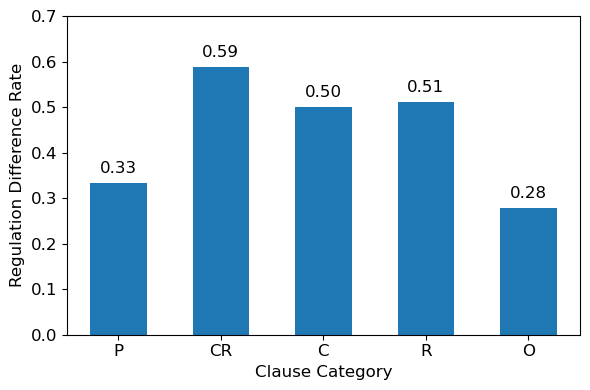

In [ ]:
categories = ["P", "CR", "C", "R", "O"]
diff_rates = [0.333333, 0.58888888, 0.5, 0.5104166, 0.277777]

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(categories, diff_rates, width=0.55)

ax.set_xlabel("Clause Category", fontsize=12)
ax.set_ylabel("Regulation Difference Rate", fontsize=12)

# 坐标轴刻度字体
ax.tick_params(axis="both", labelsize=12)

# y轴范围和刻度
ax.set_ylim(0, 0.7)
ax.set_yticks(np.arange(0, 0.71, 0.1))

# 在柱子上显示数值
for bar, value in zip(bars, diff_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.tight_layout()

plt.savefig(
    output_fig,
    bbox_inches="tight"
)

plt.show()

In [ ]:

# # =========================
# # 13. Format Excel
# # =========================

# wb = load_workbook(output_path)

# header_fill = PatternFill("solid", fgColor="D9EAF7")
# header_font = Font(bold=True)
# thin_border = Border(
#     left=Side(style="thin", color="DDDDDD"),
#     right=Side(style="thin", color="DDDDDD"),
#     top=Side(style="thin", color="DDDDDD"),
#     bottom=Side(style="thin", color="DDDDDD"),
# )

# for ws in wb.worksheets:
#     ws.freeze_panes = "A2"

#     # header style
#     for cell in ws[1]:
#         cell.font = header_font
#         cell.fill = header_fill
#         cell.alignment = Alignment(horizontal="center", vertical="center")
#         cell.border = thin_border

#     # body style
#     for row in ws.iter_rows(min_row=2):
#         for cell in row:
#             cell.border = thin_border
#             cell.alignment = Alignment(vertical="center")

#     # column width
#     for col in ws.columns:
#         max_len = 0
#         col_letter = get_column_letter(col[0].column)

#         for cell in col:
#             value = cell.value
#             if value is not None:
#                 max_len = max(max_len, len(str(value)))

#         ws.column_dimensions[col_letter].width = min(max(max_len + 2, 10), 35)

#     # percent format
#     for row in ws.iter_rows():
#         for cell in row:
#             if cell.value is not None and isinstance(cell.value, float):
#                 if "Rate" in str(ws.cell(row=1, column=cell.column).value) \
#                    or "Contribution" in str(ws.cell(row=1, column=cell.column).value):
#                     cell.number_format = "0.0%"

#     # 对 matrix sheets 加 color scale
#     if "Matrix" in ws.title:
#         max_row = ws.max_row
#         max_col = ws.max_column
#         if max_row >= 2 and max_col >= 2:
#             data_range = f"B2:{get_column_letter(max_col)}{max_row}"
#             ws.conditional_formatting.add(
#                 data_range,
#                 ColorScaleRule(
#                     start_type="min",
#                     start_color="FFFFFF",
#                     mid_type="percentile",
#                     mid_value=50,
#                     mid_color="FFD966",
#                     end_type="max",
#                     end_color="F8696B"
#                 )
#             )

In [ ]:
# wb.save(output_path)


# # =========================
# # 14. Print key results
# # =========================

# print("\nSaved to:", output_path)

# print("\nTop 10 region pairs by regulation difference:")
# print(pair_summary.head(10).to_string(index=False))

# print("\nLargest pair:")
# print(f"{largest_r1} vs {largest_r2}")
# print("Diff Count:", int(largest_pair["Diff Count"]))
# print("Diff Rate:", f"{largest_pair['Diff Rate']:.1%}")

# print("\nLargest pair category breakdown:")
# print(largest_pair_category.to_string(index=False))


Saved to: dataset\out_R\region_pair_difference_analysis.xlsx

Top 10 region pairs by regulation difference:
 Rank   Region 1 Region 2  Diff Count  Total Clauses  Diff Rate  P Diff  P Total  P Diff Rate  P Contribution  CR Diff  CR Total  CR Diff Rate  CR Contribution  C Diff  C Total  C Diff Rate  C Contribution  R Diff  R Total  R Diff Rate  R Contribution  O Diff  O Total  O Diff Rate  O Contribution
    1 California    Saudi          26             46   0.565217      13       20         0.65        0.500000        3         5           0.6         0.115385       0        2          0.0        0.000000       8       16       0.5000        0.307692       2        3     0.666667        0.076923
    2 California    India          25             46   0.543478       7       20         0.35        0.280000        2         5           0.4         0.080000       2        2          1.0        0.080000      11       16       0.6875        0.440000       3        3     1.000000        0.1200